In [33]:
from pso import PSO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec

In [34]:
def ackley(x, a=20, b=0.2, c=2*np.pi):
    d = len(x)
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(c * x))
    term1 = -a * np.exp(-b * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + a + np.exp(1)

def rosenbrock(x):
    return np.sum(100.0*(x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

def cross_in_tray(x):
    term1 = np.sin(x[0]) * np.sin(x[1])
    term2 = np.exp(np.abs(100 - np.sqrt(x[0]**2 + x[1]**2)/np.pi))
    return -0.0001 * (np.abs(term1 * term2) + 1)**0.1

def holder_table(x):
    return -np.abs(np.sin(x[0]) * np.cos(x[1]) * 
                   np.exp(np.abs(1 - np.sqrt(x[0]**2 + x[1]**2)/np.pi)))

def mccormick(x):
    return np.sin(x[0] + x[1]) + (x[0] - x[1])**2 - 1.5*x[0] + 2.5*x[1] + 1

def styblinski_tang(x):
    return 0.5 * np.sum(x**4 - 16*x**2 + 5*x)

In [ ]:
def create_combined_pso_animation(
    func,
    bounds,
    best_history,
    all_positions,
    num_particles,
    alpha1,
    alpha2,
    w_min,
    w_max,
    theoretical_min = "Unknown",
    save_gif=False,
    show=True,
    fps=10
):
    iterations = len(best_history)
    best_points = [np.array(pos) for pos, _ in best_history]
    convergence = [score for _, score in best_history]

    x_vals = np.linspace(bounds[0, 0], bounds[0, 1], 100)
    y_vals = np.linspace(bounds[1, 0], bounds[1, 1], 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.apply_along_axis(func, 1, np.c_[X.ravel(), Y.ravel()]).reshape(X.shape)

    fig = plt.figure(figsize=(10, 8))
    fig.suptitle(f"{func.__name__.capitalize()} Function Optimization", fontsize=16, fontweight='bold')
    gs = GridSpec(2, 2, height_ratios=[1, 1])

    # --- Subplot 1: 3D surface --- #
    ax1 = fig.add_subplot(gs[0, 0], projection='3d')
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.set_title("Surface")
    pop_scatter3d = ax1.scatter([], [], [], color='red', s=10)
    best_scatter3d = ax1.scatter([], [], [], color='yellow', s=40)

    # --- Subplot 2: Contour --- #
    ax2 = fig.add_subplot(gs[0, 1])
    contour = ax2.contourf(X, Y, Z, levels=50, cmap='turbo')
    fig.colorbar(contour, ax=ax2)
    particles2d = ax2.scatter([], [], color='red', s=10)
    best2d = ax2.scatter([], [], color='yellow', s=40)
    ax2.set_xlim(bounds[0])
    ax2.set_ylim(bounds[1])
    ax2.set_title("Contour")

    # --- Subplot 3: Convergence --- #
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_xlim(0, iterations)
    ax3.set_ylim(min(convergence) - 1, max(convergence) + 1)
    line, = ax3.plot([], [], 'b-o', markersize=2)
    ax3.set_title("Convergence Curve")
    ax3.set_xlabel("Iteration")
    ax3.set_ylabel("Best Function Value")

    # --- Subplot 4: Info Panel --- #
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    info_text = ax4.text(0, 0.8, "", fontsize=10, verticalalignment='top', family='monospace')

    # --- Animation Functions --- #
    def init():
        pop_scatter3d._offsets3d = ([], [], [])
        best_scatter3d._offsets3d = ([], [], [])
        particles2d.set_offsets(np.zeros((0, 2)))
        best2d.set_offsets(np.zeros((0, 2)))
        line.set_data([], [])
        info_text.set_text("")
        return pop_scatter3d, best_scatter3d, particles2d, best2d, line, info_text

    def update(frame):
        print(f"Updating frame {frame}")
        pop = np.array(all_positions[frame])
        best = np.array(best_points[frame])
        best_val = func(best)

        # 3D plot
        pop_z = np.array([func(p) for p in pop])
        pop_scatter3d._offsets3d = (pop[:, 0], pop[:, 1], pop_z)
        best_scatter3d._offsets3d = ([best[0]], [best[1]], [best_val])

        # 2D plot
        particles2d.set_offsets(pop)
        best2d.set_offsets([best[0], best[1]])

        # Convergence
        line.set_data(range(frame + 1), convergence[:frame + 1])

        # Info panel
        info_text.set_text(
            f"Iteration: {frame + 1}/{len(all_positions)}\n"
            f"Particles: {num_particles}\n"
            f"Best Position: {np.round(best, 4)}\n"
            f"Best Value Founded: {best_val:.6f}\n"
            f"Theoretical min = {theoretical_min}\n"
            f"Function: {func.__name__}\n"
            f"Parameters:\n"
            f"  alpha1={alpha1}, alpha2={alpha2}\n"
            f"  w in [{w_min}, {w_max}]\n"
        )

        return pop_scatter3d, best_scatter3d, particles2d, best2d, line, info_text

    print("Frames:", len(all_positions))
    print("Shape of first frame:", np.array(all_positions[0]).shape)
    print("Shape of best_history[0]:", np.array(best_history[0][0]).shape)
    ani = animation.FuncAnimation(fig, update, frames=iterations, init_func=init, blit=False, repeat=False)

    if save_gif:
        ani.save(f"gifs/{func.__name__.capitalize()}_visualization.gif", writer="pillow", fps=fps, loop=0)
    if show:
        plt.show()
    else:
        plt.close()

    return ani


In [36]:
# pso = PSO(
#     fitness_func = styblinski_tang,
#     num_particles=100,
#     dim=2,
#     pos_bounds=np.array([[-5, 5], [-5, 5]]),
#     vel_bounds=(-1, 1),
#     max_iter = 10,
#     alpha1=2,
#     alpha2=2,
#     w_max=0.9,
#     w_min=0.4,
# )

# best_pos, best_score, history_best, history_all_positions = pso.run()

# create_combined_pso_animation(
#     func = styblinski_tang,
#     bounds=np.array([[-5, 5], [-5, 5]]),
#     best_history=history_best,
#     all_positions=history_all_positions,
#     num_particles=20,
#     alpha1=2,
#     alpha2=2,
#     w_min=0.4,
#     w_max=0.9,
#     save_gif=True,  
#     show=True
# )


In [37]:
func_info = {
    "ackley": (ackley, (-5, 5), (-5, 5), (0, 0), 0),
    "rosenbrock": (rosenbrock, (-5, 5), (-5, 5), (1, 1), 0),
    "cross_in_tray": (cross_in_tray, (-10, 10), (-10, 10), (1.34941, 1.34941), -2.06261),
    "holder_table": (holder_table, (-10, 10), (-10, 10), (8.05502, 9.66459), -19.2085),
    "mccormick": (mccormick, (-1.5, 4), (-3, 4), (-0.54719, -1.54719), -1.9133),
    "styblinski_tang": (styblinski_tang, (-5, 5), (-5, 5), (-2.903534, -2.903534), -78.33198)
}

In [38]:
import time
import pandas as pd

In [39]:
# результат будет сохраняться здесь
results = []

num_runs = 10
num_particles_values = [20, 50, 100, 250]
alpha1_values = [1, 1.5, 2]
alpha2_values = [1, 1.5, 2]

max_iter = 100
w_max = 0.9
w_min = 0.2
epsilon_target = 1e-6

enable_shaking = False
stagnation_iter = 15
shake_probability = 0.7
shake_amplitude = 0.5
epsilon_stagnation = 1e-6

start = False

if start:
    for func_name, (func, x_bound, y_bound, best_point, theoretical_min) in func_info.items():
        bounds = np.array([x_bound, y_bound])
        
        best_avg_cost = None
        best_params = None
        param_results = {}

        print(f"\n Optimizing {func_name.upper()}...\n")
        
        for n in num_particles_values:
            for a1 in alpha1_values:
                for a2 in alpha2_values:

                    cost_list = []
                    iter_list = []
                    time_list = []
                    score_list = []

                    for run in range(num_runs):
                        pso_solver = PSO(
                            func, n, 2, bounds, (-1, 1), max_iter,
                            a1, a2, w_max, w_min,
                            enable_shaking, stagnation_iter, shake_probability, shake_amplitude,
                            target_global_min=theoretical_min,
                            epsilon_target=epsilon_target,
                            epsilon_stagnation=epsilon_stagnation
                        )

                        start_time = time.time()
                        _, best_score, history_best_positions, _ = pso_solver.run()
                        end_time = time.time()

                        iterations_used = len(history_best_positions)
                        total_cost = n * iterations_used
                        elapsed_time = end_time - start_time

                        score_list.append(best_score)
                        cost_list.append(total_cost)
                        iter_list.append(iterations_used)
                        time_list.append(elapsed_time)

                    avg_cost = np.mean(cost_list)
                    avg_iters = np.mean(iter_list)
                    avg_time = np.mean(time_list)
                    avg_score = np.mean(score_list)
                    delta_to_min = abs(avg_score - theoretical_min)

                    param_results[(n, a1, a2)] = avg_cost

                    # Обновляем лучший вариант
                    if best_avg_cost is None or avg_cost < best_avg_cost:
                        best_avg_cost = avg_cost
                        best_params = (n, a1, a2)

                    # Сохраняем каждую конфигурацию
                    results.append({
                        "function": func_name,
                        "num_particles": n,
                        "alpha1": a1,
                        "alpha2": a2,
                        "avg_cost": round(avg_cost, 2),
                        "avg_iterations": round(avg_iters, 2),
                        "avg_time_sec": round(avg_time, 4),
                        "avg_score": round(avg_score, 6),
                        "delta_to_theoretical_min": round(delta_to_min, 6)  
                    })

        print(f"Function: {func_name}")
        print(f"   Best params: num_particles={best_params[0]}, alpha1={best_params[1]}, alpha2={best_params[2]}")
        print(f"   Avg cost (particles × iters): {best_avg_cost:.2f}")
        print("-" * 50)

# Сохраняем в CSV
df = pd.DataFrame(results)
df.to_csv("pso_parameter_search_results.csv", index=False)
print("Результати збережені в 'pso_parameter_search_results.csv'")


 Optimizing ACKLEY...

Iteration 0: Global best score = 3.390511932262506
Iteration 10: Global best score = 0.43844367728165823
Iteration 20: Global best score = 0.050572886132851824
Iteration 30: Global best score = 0.004937852309030877
Iteration 40: Global best score = 0.0021864424641333535
Iteration 50: Global best score = 0.00013432915664823852
Iteration 60: Global best score = 1.6834503715479343e-06
Global minimum is within epsilon 1e-06 of target at iteration 62. Stopping.
Iteration 0: Global best score = 4.243866081175387
Iteration 10: Global best score = 0.1278650032469426
Iteration 20: Global best score = 0.007686539783002377
Iteration 30: Global best score = 0.002332979699346982
Iteration 40: Global best score = 0.0008151043605768571
Iteration 50: Global best score = 1.980445797800101e-05
Iteration 60: Global best score = 5.062016751100629e-06
Global minimum is within epsilon 1e-06 of target at iteration 69. Stopping.
Iteration 0: Global best score = 5.265069967088781
Iterat

In [40]:
df = pd.read_csv("pso_parameter_search_results.csv")

best_configs = []

for func in df["function"].unique():
    func_df = df[df["function"] == func]

    sorted_by_time = func_df.sort_values("avg_time_sec")
    for _, row in sorted_by_time.iterrows():
        if row["delta_to_theoretical_min"] <= 0.1:
            best_configs.append({
                "function": func,
                "criteria": "min_time",
                "num_particles": row["num_particles"],
                "alpha1": row["alpha1"],
                "alpha2": row["alpha2"],
                "avg_cost": row["avg_cost"],
                "avg_time_sec": row["avg_time_sec"],
                "avg_score": row["avg_score"],
                "delta_to_theoretical_min": row["delta_to_theoretical_min"]
            })
            break  

    sorted_by_cost = func_df.sort_values("avg_cost")
    for _, row in sorted_by_cost.iterrows():
        if row["delta_to_theoretical_min"] <= 0.1:
            best_configs.append({
                "function": func,
                "criteria": "min_cost",
                "num_particles": row["num_particles"],
                "alpha1": row["alpha1"],
                "alpha2": row["alpha2"],
                "avg_cost": row["avg_cost"],
                "avg_time_sec": row["avg_time_sec"],
                "avg_score": row["avg_score"],
                "delta_to_theoretical_min": row["delta_to_theoretical_min"]
            })
            break  

best_df = pd.DataFrame(best_configs)
best_df.to_csv("pso_best_configs_by_time_and_cost.csv", index=False)

print("✅ Найкращі конфігурації (delta ≤ 0.1) збережені в 'pso_best_configs_by_time_and_cost.csv'")

✅ Найкращі конфігурації (delta ≤ 0.1) збережені в 'pso_best_configs_by_time_and_cost.csv'



🔄 Animation ackley with parametres: n=20, alpha1=1.5, alpha2=1.0
Iteration 0: Global best score = 2.9997793106704944
Iteration 10: Global best score = 0.3069825482986954
Iteration 20: Global best score = 0.02103850090040682
Iteration 30: Global best score = 0.005890304484364339
Iteration 40: Global best score = 0.0004892329382646388
Iteration 50: Global best score = 4.755719227533817e-05
Iteration 60: Global best score = 8.283995012181578e-06
Global minimum is within epsilon 1e-06 of target at iteration 67. Stopping.
Frames: 68
Shape of first frame: (20, 2)
Shape of best_history[0]: (2,)


TypeError: Animation.__init__() got an unexpected keyword argument 'loop'

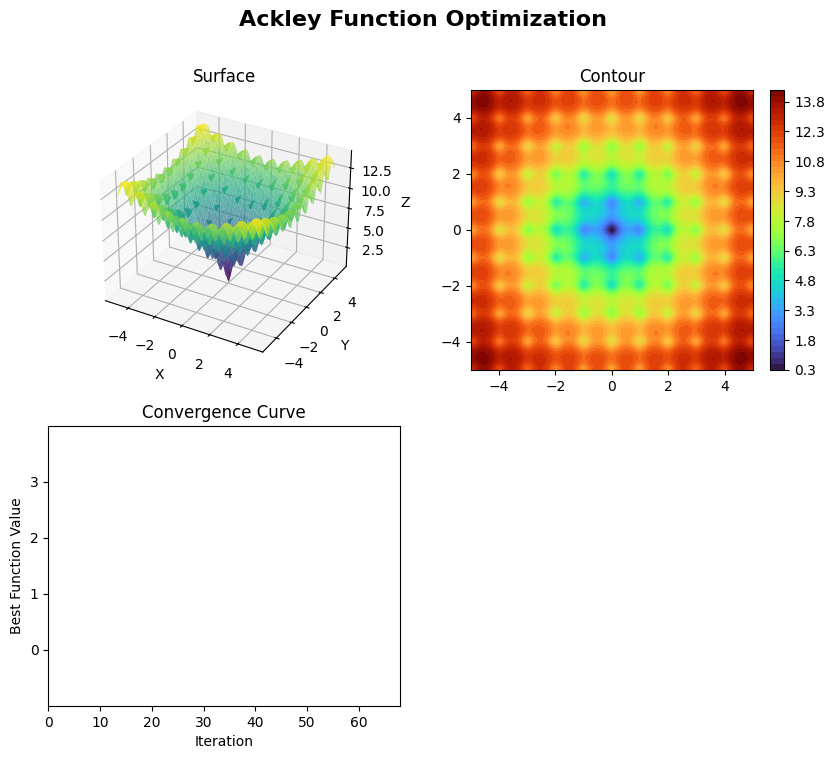

In [41]:
best_df = best_df[best_df["criteria"] == "min_time"]

for _, row in best_df.iterrows():
    func_name = row["function"]
    n = int(row["num_particles"])
    alpha1 = float(row["alpha1"])
    alpha2 = float(row["alpha2"])
    
    func, x_bound, y_bound, best_point, theoretical_min = func_info[func_name]
    bounds = np.array([x_bound, y_bound])
    
    print(f"\n🔄 Animation {func_name} with parametres: n={n}, alpha1={alpha1}, alpha2={alpha2}")

    pso_solver = PSO(
        fitness_func=func,
        num_particles=n,
        dim=2,
        pos_bounds=bounds,
        vel_bounds=(-1, 1),
        max_iter=100,
        alpha1=alpha1,
        alpha2=alpha2,
        w_max=0.9,
        w_min=0.2,
        enable_shaking=False,
        stagnation_iter=15,
        shake_probability=0.7,
        shake_amplitude=0.5,
        epsilon_stagnation=1e-6,
        target_global_min=theoretical_min,
        epsilon_target=1e-6
    )

    best_pos, best_score, history_best, all_positions = pso_solver.run()


    create_combined_pso_animation(
        func=func,
        bounds=bounds,
        best_history=history_best,
        all_positions=all_positions,
        num_particles=n,
        alpha1=alpha1,
        alpha2=alpha2,
        w_min=0.2,
        w_max=0.9,
        theoretical_min=theoretical_min,
        save_gif=True,
        show=False
    )

In [43]:
df = pd.read_csv("pso_best_configs_by_time_and_cost.csv")

styled_df = df.style\
    .set_caption("Best PSO Configurations by Time and Cost")\
    .background_gradient(subset=["avg_cost"], cmap="Blues")\
    .background_gradient(subset=["avg_time_sec"], cmap="Greens")\
    .format({
        "avg_cost": "{:.0f}",
        "avg_time_sec": "{:.4f}",
        "avg_score": "{:.6f}",
        "delta_to_theoretical_min": "{:.2e}"
    })\
    .hide(axis="index")

styled_df

function,criteria,num_particles,alpha1,alpha2,avg_cost,avg_time_sec,avg_score,delta_to_theoretical_min
ackley,min_time,20,1.500000,1.000000,1392,0.0495,0.000001,1.00e-06
ackley,min_cost,20,1.000000,1.000000,1316,0.0681,0.000001,1.00e-06
rosenbrock,min_time,20,1.500000,1.500000,1100,0.0340,0.000001,1.00e-06
rosenbrock,min_cost,20,1.000000,1.000000,1012,0.0360,0.000000,0.00e+00
cross_in_tray,min_time,20,1.000000,1.500000,604,0.0142,-2.062610,0.00e+00
cross_in_tray,min_cost,20,1.500000,1.500000,594,0.0173,-2.062610,0.00e+00
holder_table,min_time,50,1.000000,1.500000,1935,0.0510,-19.208500,0.00e+00
holder_table,min_cost,50,1.000000,1.000000,1895,0.0521,-19.208501,1.00e-06
mccormick,min_time,20,2.000000,2.000000,2000,0.0435,-1.913223,7.70e-05
mccormick,min_cost,20,1.000000,1.000000,2000,0.0702,-1.913223,7.70e-05
